# Fama-French 三因子模型 — 学习笔记

本 notebook 是 [CAPM.ipynb](CAPM.ipynb) 的续篇：CAPM 用**单一**市场因子 β 解释收益；
Fama & French (1993) 发现，加入**规模(SMB)**与**价值(HML)**两个因子后，对横截面收益的解释力大幅提升。

**学习路径**：构建 2×3 分组组合 → 合成 SMB / HML / MKT 因子 → 因子表现检验 → 时序回归看 α 与解释力 → GRS 联合检验

---

## 一、理论公式 ↔ 代码变量

| 概念 | 公式 | 代码变量 |
|------|------|----------|
| 三因子回归 | $R_i-r_f=\alpha+\beta_{MKT}MKT+\beta_{SMB}SMB+\beta_{HML}HML+\varepsilon$ | `sm.OLS` |
| 市场因子 | $MKT=R_m-r_f$ | `ff['MKT']` |
| 规模因子 | $SMB=\overline{R_{small}}-\overline{R_{big}}$ | `ff['SMB']` |
| 价值因子 | $HML=\overline{R_{highBP}}-\overline{R_{lowBP}}$ | `ff['HML']` |
| 账面市值比 | $BP=B/M=1/PB$ | `bp` |
| 规模代理 | 总市值 | `mc` |

### 📖 通俗理解

CAPM 说：一只股票赚不赚钱，只看它跟大盘走得近不近（β）。跟大盘同步的（β 高），波动大、预期收益就高；跟大盘不搭边的，你就该拿低收益。

**Fama-French 说：不对。除了大盘，还有两个因素在起作用：**

- **小盘股 vs 大盘股（SMB，Small Minus Big）**：同等条件下，小公司往往比大公司涨得多。就像街边小店比沃尔玛更容易翻倍——不是因为小店"更好"，而是因为它的成长空间和风险结构不一样。模型用 SMB 因子来捕捉这个效应：做多小盘、做空大盘，赚的就是"规模溢价"。
- **便宜股 vs 贵股（HML，High Minus Low）**：市净率（PB）低 = "便宜"；PB 高 = "贵"。长期看，便宜的股票往往比贵的股票收益好——就像打折买好货 vs. 溢价追热门。HML 做多便宜股（高账面市值比）、做空贵股（低账面市值比），赚的就是"价值溢价"。

**模型做的事**：把一只股票的收益拆成三块——市场给的、规模给的、价值给的。剩下来的部分叫 **α（alpha）**，就是"三个因子都解释不了的部分"。如果某只股票的 α 显著为正，说明它在这三因子框架下"超额完成任务"；α 为负，就是"不达预期"。

## 二、与 CAPM 的关系

CAPM 是三因子模型在 $\beta_{SMB}=\beta_{HML}=0$ 时的**特例**。若 FF3 的 α 比 CAPM 的 α 更接近 0、
$R^2$ 更高、GRS 联合检验更不显著，说明规模与价值因子确实捕捉了 CAPM 漏掉的系统性风险。

> 💡 **一句话**：CAPM 是"单镜头"看股票（只透过大盘）；FF3 是"三镜头"（大盘 + 规模 + 价值）。多两个角度，解释力自然更强。本笔记会分别用"逐个看 α"和"GRS 联合检验"两种方式，看这三个镜头是否够用。

## 三、原文与参考资料

- **原始论文**：Fama, E. F., & French, K. R. (1993). *Common risk factors in the returns on stocks and bonds.* Journal of Financial Economics, 33(1), 3–56. [DOI:10.1016/0304-405X(93)90023-5](https://doi.org/10.1016/0304-405X(93)90023-5) ｜ [公开 PDF](https://www.bauer.uh.edu/rsusmel/phd/Fama-French_JFE93.pdf)
- **官方因子数据与构建口径**：[Kenneth R. French Data Library](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html)
- **GRS 联合检验**：Gibbons, M. R., Ross, S. A., & Shanken, J. (1989). *A test of the efficiency of a given portfolio.* Econometrica, 57(5), 1121–1152. [DOI:10.2307/1913625](https://doi.org/10.2307/1913625)

> **数据口径**：股票池=中证800 成分（期初快照，教学用固定池，真实研究应逐期调整）；
> 月频；规模/价值因子取上月末值（避免前视）；行情、市值、PB 均来自米筐 `rqdatac`；
> 无风险利率用年化 2% 常数（教学简化）。经典 FF 是年度 6 月底成形 + 年报账面价值，
> 这里简化为**月度调仓 + 点位 PB**，便于学习核心思想。

In [1]:
# ===================== Part 0：环境准备 =====================
# 功能：导入依赖库、定位项目根目录、初始化米筐数据源
import sys
import os
import numpy as np             # 数值计算（均值、标准差等）
import pandas as pd            # 数据处理（表格、时间序列对齐）
import matplotlib.pyplot as plt # 画图
import statsmodels.api as sm   # OLS 时序回归：三因子回归 R_i-r_f = α + β_MKT*MKT + β_SMB*SMB + β_HML*HML + ε
import warnings
warnings.filterwarnings('ignore')

# ---- 中文字体设置（让图表能正常显示中文） ----
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ---- 定位项目根目录（兼容 notebook 从不同目录启动） ----
# 为什么要找 PROJECT_ROOT？因为 my_utils 在项目根目录下，不在 learn/ 子目录里。
# 这段代码向上查找最近的有 my_utils 文件夹的目录，然后把它加入 sys.path，
# 这样无论你从哪打开 notebook，都能正常 import my_utils。
PROJECT_ROOT = None
for _c in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '../..')]:
    _r = os.path.abspath(_c)
    if os.path.isdir(os.path.join(_r, 'my_utils')):
        PROJECT_ROOT = _r
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('未找到项目根目录（需包含 my_utils 文件夹）')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# ---- 初始化米筐数据源（RqData() 内部完成 rq.init(license)） ----
# 之后可直接用 rqdatac 模块级接口：rq.get_price、rq.get_factor 等
from my_utils.rqdata import RqData
import rqdatac as rq
RqData()
print('米筐初始化完成')

米筐初始化完成


In [ ]:
# ===================== Part 1：数据准备 =====================
# 目标：从米筐获取中证800成分股的月收益、市值（规模因子）、账面市值比（价值因子,1/市净率PB=BP），
#       以及中证800指数收益（市场因子 MKT 的基准）。
# 注意：月收益从日线行情按月聚合得到，因子值取每月末的数据点，避免前视偏差。

# ---- 时间范围与无风险利率 ----
start_date = '2021-01-01'
end_date = '2024-12-31'
rf_annual = 0.02              # 年化无风险利率 2%（教学用常数）
rf_monthly = rf_annual / 12   # 折算月无风险利率，用于三因子回归中的 R_i - r_f

# ---- 股票池：中证800成分（沪深300 + 中证500，覆盖大中盘） ----
# index_components 返回期初成分股列表，教学用固定池（真实研究会逐期调整成分）
universe = rq.index_components('000906.XSHG', date=start_date)
print(f'中证800 成分股数: {len(universe)}')

# ---- 行情：日线后复权收盘价 → 月度收益率 ----
# adjust_type='post'（后复权）：分红、拆股后价格被反推调整，使收益计算准确
# .unstack('order_book_id') 把 MultiIndex 的(order_book_id, date) 转成二维表：行=日期, 列=股票
px = rq.get_price(universe, start_date=start_date, end_date=end_date,
                  frequency='1d', fields='close', adjust_type='post')
close = px['close'].unstack('order_book_id')          # 行=交易日, 列=股票代码
m_close = close.resample('M').last()                  # 每月最后一个交易日的收盘价（月频快照）
m_ret = m_close.pct_change()                          # 月收益率 = (本月收盘/上月收盘) - 1

# ---- 规模（SMB 因子输入）与 价值（HML 因子输入） ----
# market_cap_3：总市值（元），取对数后做规模代理 → 用于 size 维度的分组
# pb_ratio_ttm：市净率（TTM），取倒数得到 BP → BP = 账面价值/市值 = 1/PB
# 注意：BP 高 = 便宜（价值股），BP 低 = 贵（成长股）——这是 HML 分组的核心依据
fac = rq.get_factor(universe, ['market_cap_3', 'pb_ratio_ttm'],
                    start_date=start_date, end_date=end_date)
mc = fac['market_cap_3'].unstack('order_book_id').resample('M').last()    # 月末总市值 → 规模分组
pb = fac['pb_ratio_ttm'].unstack('order_book_id').resample('M').last()    # 月末市净率
bp = 1.0 / pb.where(pb > 0)  # 账面市值比 = 1/市净率（PB<=0 的视为无效数据，填 NaN）

# ---- 市场组合：中证800指数月收益 —— 市场因子 MKT = R_m - r_f ----
# 用指数的 pct_change 做市场收益，反映了整个可投资市场的平均回报
idx = rq.get_price('000906.XSHG', start_date=start_date, end_date=end_date,
                   frequency='1d', fields='close')
idx_close = idx['close'].droplevel('order_book_id')  # 指数只有一个值，去掉多余的层级
idx_m = idx_close.resample('M').last().pct_change()  # 中证800 月收益率 → R_m

print(f'月份数: {m_ret.shape[0]}, 股票数: {m_ret.shape[1]}')
print(f'样本区间: {m_ret.index.min():%Y-%m} ~ {m_ret.index.max():%Y-%m}')
m_ret.iloc[:3, :4]  # 展示前3月、前4只股票的月收益矩阵

中证800 成分股数: 800
月份数: 48, 股票数: 800
样本区间: 2021-01 ~ 2024-12


order_book_id,002271.XSHE,002311.XSHE,600291.XSHG,600161.XSHG
date,,,,
2021-01-31,NaN,NaN,NaN,NaN
2021-02-28,-0.02618557,0.20802310,0.02654867,-0.08857143
2021-03-31,0.08320982,-0.01886792,-0.13218391,-0.06925050


In [3]:
# ===================== Part 2：2×3 分组构建 SMB / HML =====================
# 核心思想（对应理论表中的公式）：
#   SMB = (小盘组合均值) - (大盘组合均值)   → 做多小盘、做空大盘，捕捉"规模溢价"
#   HML = (高BP组合均值) - (低BP组合均值)  → 做多便宜股、做空贵股，捕捉"价值溢价"
#
# 经典 Fama-French (1993) 做法：
#   Size 维度：按市值中位数分 2 组 → S(小盘, Small) / B(大盘, Big)
#   Value 维度：按 BP 的 30%/70% 分位分 3 组 → L(低, Low) / M(中, Medium) / H(高, High)
#   交叉得到 6 个市值加权组合：SL SM SH  BL BM BH
#
# ⚠️ 关键防前视（look-ahead bias）：
#   第 t 月的组合收益，用第 t-1 月末观测到的 size 和 bp 来分组！
#   就像你用 6 月底的财报数据预测 7-12 月的收益——你用"当时已经知道的信息"，
#   而不是"后来才知道的信息"。如果拿 t 月的分组依据去解释 t 月的收益，就是作弊。

# ---- 对齐三张表的股票和月份（只保留共有的股票/日期） ----
common = m_ret.columns.intersection(mc.columns).intersection(bp.columns)
m_ret_a, mc_a, bp_a = m_ret[common], mc[common], bp[common]
months = m_ret_a.index  # 所有月份的列表，按月遍历

records = []
for i in range(1, len(months)):       # 从第 2 个月开始（需要第 1 个月的数据做分组）
    t, t_prev = months[i], months[i - 1]  # t = 本月（收益发生月），t_prev = 上月（分组依据）

    # 上月末观测到的分组变量（防前视！在交易 t 月之前已知的值）
    size = mc_a.loc[t_prev]    # 上月末总市值 → 决定"大还是小"
    val = bp_a.loc[t_prev]     # 上月末账面市值比 → 决定"便宜还是贵"
    ret = m_ret_a.loc[t]       # 本月实际收益 → 分组后看各组表现

    # 筛选有效数据：三张表都不缺、且市值为正（剔除停牌或退市股）
    mask = size.notna() & val.notna() & ret.notna() & (size > 0)
    size, val, ret = size[mask], val[mask], ret[mask]
    if len(size) < 30:         # 太少股票不构成有效分组（极端行情保护）
        continue

    # ---- Size 分组：按市值中位数一刀切 ----
    big = size >= size.median()  # True = 大盘(B), False = 小盘(S)

    # ---- Value 分组：按 BP 的 30% 和 70% 分位数切三刀 ----
    q30, q70 = val.quantile(0.3), val.quantile(0.7)
    low, high = val <= q30, val >= q70   # low = 最低30%(成长/贵), high = 最高30%(价值/便宜)
    mid = ~low & ~high                    # 中间40%

    def vw(sel):
        """组内市值加权收益（value-weighted return）。
        FF1993 原文用的是市值加权：大市值的股票在该组合中的贡献更大。
        为什么用市值加权？因为这更贴近真实投资者的持仓——你不会等额持有茅台和小盘股。"""
        if sel.sum() == 0:
            return np.nan
        w = size[sel]                                  # 权重 = 该组内每只股票的总市值
        return float((ret[sel] * w).sum() / w.sum())   # 加权平均收益 = Σ(权重×收益) / Σ权重

    # 6 个组合的市值加权收益（按顺序：小盘×低BP、小盘×中BP、小盘×高BP、大盘×低BP、大盘×中BP、大盘×高BP）
    SL, SM, SH = vw(~big & low), vw(~big & mid), vw(~big & high)  # 小盘三组
    BL, BM, BH = vw(big & low), vw(big & mid), vw(big & high)     # 大盘三组

    # ---- 构建因子（理论表核心公式） ----
    # SMB = 小盘三组的平均收益 - 大盘三组的平均收益
    # 取平均而不是某个分位，是为了消除价值维度的干扰
    smb = (SL + SM + SH) / 3 - (BL + BM + BH) / 3

    # HML = (高BP两组平均) - (低BP两组平均)
    # 取两组平均而非一组，同样是为了消除规模维度的干扰
    hml = (SH + BH) / 2 - (SL + BL) / 2

    records.append(dict(month=t, SMB=smb, HML=hml,
                        SL=SL, SM=SM, SH=SH, BL=BL, BM=BM, BH=BH))

# 因子数据框：行=月, 列={SMB, HML, MKT}
ff = pd.DataFrame(records).set_index('month')
# MKT = 市场月度收益 - 无风险利率（理论表中的市场因子 R_m - r_f）
ff['MKT'] = idx_m.reindex(ff.index) - rf_monthly
ff = ff.dropna(subset=['SMB', 'HML', 'MKT'])  # 去掉任何因子缺失的月份
print(f'有效月份数: {len(ff)}')
ff[['MKT', 'SMB', 'HML']].head()  # 展示三因子时间序列的前5行

有效月份数: 47


,MKT,SMB,HML
month,,,
2021-02-28,-0.00325590,0.02932205,0.07598413
2021-03-31,-0.04765652,0.04841085,0.08331338
2021-04-30,0.01822046,0.00647067,-0.06558467
2021-05-31,0.03823437,-0.00157147,-0.00832666
2021-06-30,-0.01466116,0.01657329,-0.01955744


=== 因子月均收益 t 检验 ===
 因子      月均      年化   年化波动      t值
MKT -0.0058 -0.0698 0.1897 -0.7280
SMB  0.0060  0.0724 0.1339  1.0696
HML  0.0127  0.1529 0.1853  1.6331


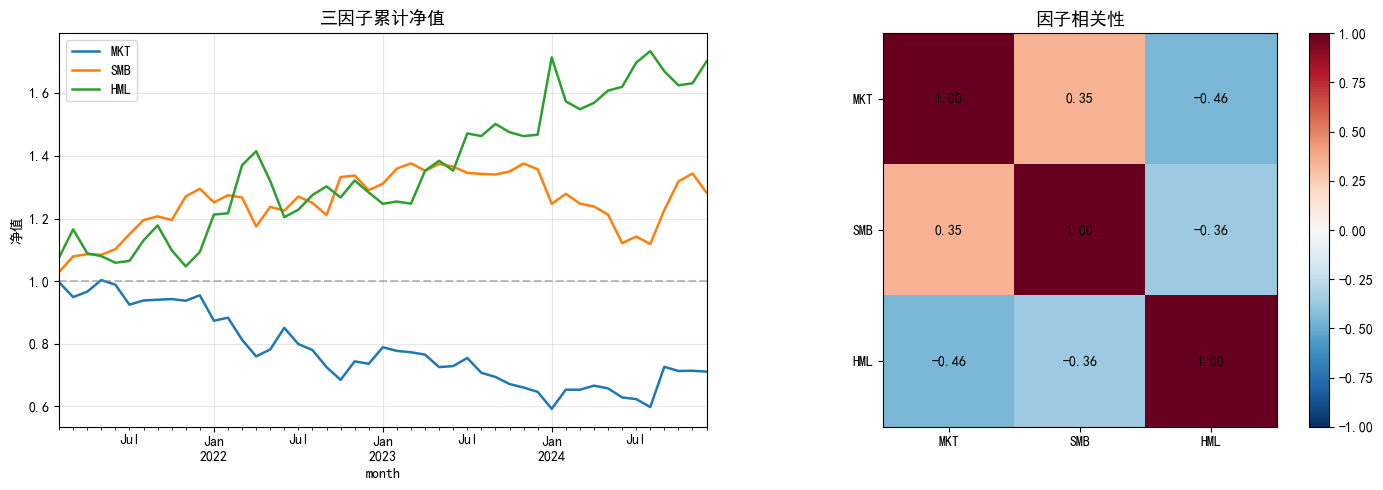

In [4]:
# ===================== Part 3：三因子表现与显著性 =====================
# 看什么：①每个因子的月均收益、年化收益和 t 值（是否显著不为0）；
#         ②因子的累计净值走势（1块钱什么时候变成多少钱）；
#         ③因子之间的相关性（是互补还是重复）。

factors = ['MKT', 'SMB', 'HML']

# ---- 月度均值显著性 t 检验 ----
# H0（原假设）：因子月均收益 = 0。如果 t 值绝对值 > 2，说明统计显著，这个因子确实在"赚"或"亏"钱。
# t = (样本均值 - 0) / (样本标准差 / sqrt(样本数))
print('=== 因子月均收益 t 检验 ===')
summary = []
for f in factors:
    x = ff[f].dropna()
    t_stat = x.mean() / (x.std(ddof=1) / np.sqrt(len(x)))  # 单样本双侧 t 检验统计量
    summary.append(dict(因子=f, 月均=x.mean(), 年化=x.mean() * 12,   # 月收益 × 12 ≈ 年化收益（复利简化）
                        年化波动=x.std(ddof=1) * np.sqrt(12), t值=t_stat))  # 月波动 × sqrt(12) ≈ 年化波动
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

# ---- 因子累计净值 ----
# 1 + 月收益 的连乘 = "1块钱投进去，到现在变成多少"
nav = (1 + ff[factors]).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
nav.plot(ax=axes[0], linewidth=1.8)
axes[0].set_title('三因子累计净值', fontsize=13)
axes[0].axhline(1, color='gray', ls='--', alpha=0.5)  # 1.0 基准线（不赚不亏）
axes[0].set_ylabel('净值'); axes[0].grid(True, alpha=0.3); axes[0].legend()

# ---- 因子相关性热图 ----
# 低相关 = 因子互补（各自捕捉不同的风险维度）；高相关 = 信息重复（其中一个可能是冗余的）
corr = ff[factors].corr()
im = axes[1].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)   # 红=负相关, 蓝=正相关
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(factors)
axes[1].set_yticks(range(3)); axes[1].set_yticklabels(factors)
for r in range(3):
    for c in range(3):
        axes[1].text(c, r, f'{corr.iloc[r, c]:.2f}', ha='center', va='center')
axes[1].set_title('因子相关性', fontsize=13)
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

=== 6 组合：CAPM vs FF3 回归（alpha 已年化）===
组合  CAPM_alpha  CAPM_R2  FF3_alpha  FF3_R2  FF3_t_alpha  b_MKT  b_SMB  b_HML
SL       0.109    0.727      0.058   0.974        2.335  0.878  0.940 -0.269
SM       0.159    0.773      0.098   0.943        3.377  0.829  0.711 -0.016
SH       0.156    0.631     -0.000   0.977       -0.016  1.081  0.768  0.718
BL      -0.045    0.884      0.032   0.973        1.563  1.024 -0.340 -0.386
BM       0.049    0.844      0.033   0.884        1.000  0.943 -0.073  0.191
BH       0.151    0.393      0.090   0.929        4.033  0.821 -0.168  0.628

平均 |alpha|：CAPM=0.1116, FF3=0.0517
平均 R^2：CAPM=0.7084, FF3=0.9466
解读：FF3 的平均 |alpha| 更小、R^2 更高，说明 SMB/HML 捕捉了 CAPM 漏掉的系统性风险。


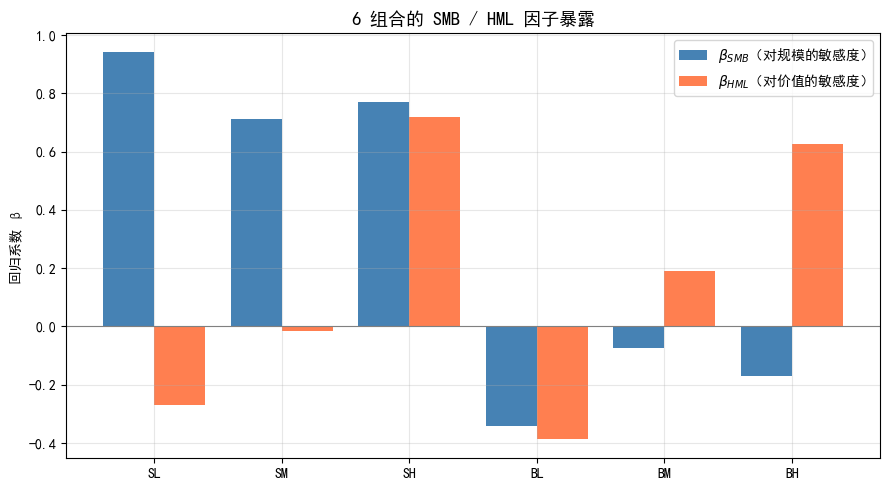

In [5]:
# ===================== Part 4：时序回归（FF3 vs CAPM 解释力对比） =====================
# 核心问题（对应理论表）：FF3 比 CAPM 的额外解释力体现在哪？
#
# 测试资产（被解释变量）：6 个 size×BP 组合（SL, SM, SH, BL, BM, BH）的超额收益 R-R_f
# 回归模型：
#   CAPM:  R_i - r_f = α + β_MKT * MKT            + ε   （只有市场一个因子）
#   FF3:   R_i - r_f = α + β_MKT * MKT + β_SMB * SMB + β_HML * HML + ε   （三因子）
#
# 判断标准：
#   - α 是否更接近 0？（α=截距项，理论上 CAMP/FF3 已经把系统性风险解释完了，α 应该为零；
#     如果 FF3 的 α 绝对值比 CAPM 小，说明 FF3 解释了更多系统性风险）
#   - R^2 是否更高？（R^2 = 被解释的方差占比，越高越好）
#   - 小盘组合(S*)的 β_SMB 是否更大？（应该更大，因为它们确实偏小盘）
#   - 高BP组合(*H)的 β_HML 是否更大？（应该更大，因为它们确实偏价值）

test_assets = ['SL', 'SM', 'SH', 'BL', 'BM', 'BH']
rows = []
for a in test_assets:
    # y = 被解释变量 = 组合月度超额收益 = R_组合 - r_f
    y = (ff[a] - rf_monthly).dropna()
    idx_common = y.index

    # ---- CAPM 回归：用市场收益解释该组合的收益 ----
    # sm.add_constant 自动加一列常数 1（作为 α 的系数）
    X1 = sm.add_constant(ff.loc[idx_common, ['MKT']])   # 解释变量只有 MKT
    m1 = sm.OLS(y, X1).fit()

    # ---- FF3 回归：用市场+规模+价值三个因子解释该组合的收益 ----
    X3 = sm.add_constant(ff.loc[idx_common, ['MKT', 'SMB', 'HML']])  # 解释变量=三因子
    m3 = sm.OLS(y, X3).fit()

    # 记录结果：年化 α（月 α × 12）、各因子的 β 系数（即暴露程度）
    rows.append(dict(
        组合=a,
        CAPM_alpha=m1.params['const'] * 12,    # 年化 α —— CAPM 漏掉"超额回报"
        CAPM_R2=m1.rsquared,                   # CAPM 的解释力
        FF3_alpha=m3.params['const'] * 12,     # 年化 α —— FF3 漏掉的更少
        FF3_R2=m3.rsquared,                    # FF3 的解释力（应该 > CAPM_R2）
        FF3_t_alpha=m3.tvalues['const'],       # α 的 t 值：|t|<2 说明 α 不显著（模型解释良好）
        b_MKT=m3.params['MKT'],                # 对市场因子的 β 暴露
        b_SMB=m3.params['SMB'],                # 对规模因子的 β 暴露
        b_HML=m3.params['HML'],                # 对价值因子的 β 暴露
    ))
reg = pd.DataFrame(rows)
print('=== 6 组合：CAPM vs FF3 回归（alpha 已年化）===')
print(reg.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

# 汇总对比：FF3 应该比 CAPM 的 |α| 更小、R^2 更高
print(f'\n平均 |alpha|：CAPM={reg["CAPM_alpha"].abs().mean():.4f}, FF3={reg["FF3_alpha"].abs().mean():.4f}')
print(f'平均 R^2：CAPM={reg["CAPM_R2"].mean():.4f}, FF3={reg["FF3_R2"].mean():.4f}')
print('解读：FF3 的平均 |alpha| 更小、R^2 更高，说明 SMB/HML 捕捉了 CAPM 漏掉的系统性风险。')

# ---- 图表：6 组合的因子暴露（b_SMB 和 b_HML） ----
# 验证：名称带 S 的组合（小盘）b_SMB 应该大、带 H 的组合（价值）b_HML 应该大
fig, ax = plt.subplots(figsize=(9, 5))
xpos = np.arange(len(test_assets))
ax.bar(xpos - 0.2, reg['b_SMB'], width=0.4, label=r'$\beta_{SMB}$（对规模的敏感度）', color='steelblue')
ax.bar(xpos + 0.2, reg['b_HML'], width=0.4, label=r'$\beta_{HML}$（对价值的敏感度）', color='coral')
ax.set_xticks(xpos); ax.set_xticklabels(test_assets)
ax.axhline(0, color='gray', lw=0.8)
ax.set_title('6 组合的 SMB / HML 因子暴露', fontsize=13)
ax.set_ylabel('回归系数 β'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [6]:
# ===================== Part 5：GRS 联合检验 =====================
# 为什么需要 GRS？Part 4 的 OLS 回归只能逐个看 α 是否为 0；
# 但可能存在某个组合的 α 恰好为零、另一个也恰好，只是偶然——需要一起检验才严谨。
# GRS (Gibbons-Ross-Shanken, 1989) 同时检验【所有】测试资产的 α 是否【联合】为 0。
#
# GRS 统计量公式（理论）：
#   GRS = (T-N-K)/N  ·  (a' Σ⁻¹ a) / (1 + f̄' Ω⁻¹ f̄)  ~  F(N, T-N-K)
#   其中 T=期数, N=测试资产数, K=因子数, a=N×1 截距向量, Σ=残差协方差, f̄=因子均值, Ω=因子协方差
#
# 解读：p 值越大越好——说明越不能拒绝"α 全为 0"的原假设，模型越完整。
from scipy import stats  # scipy.stats 提供 F 分布的累积分布函数，用于算 p 值


def grs_test(excess_assets, factors):
    """GRS 联合检验函数

    参数:
      excess_assets: DataFrame, 各测试资产（列）的月度超额收益序列（行），即 R_i - r_f
      factors:       DataFrame, 各因子（列）的月度收益序列（行），即 MKT, SMB, HML 等
    返回:
      (GRS统计量, p值, 测试资产数N, 因子数K, 期数T)
    """
    F = factors.values
    T, K = F.shape           # T=样本期数, K=因子个数
    N = excess_assets.shape[1]  # N=测试资产个数（本题中为 6 个 size×BP 组合）

    # 第一步：对每个测试资产做时序回归，收集所有 α 和残差
    Xc = sm.add_constant(F)      # 设计矩阵：加一列常数 1（对应截距 α）
    alphas, resid = [], []
    for c in excess_assets.columns:
        m = sm.OLS(excess_assets[c].values, Xc).fit()
        alphas.append(m.params[0])    # 截距 = α（该资产的超额收益中因子解释不了的部分）
        resid.append(m.resid)         # 回归残差 = ε（用于估计残差协方差矩阵 Σ）
    a = np.array(alphas)             # α 向量 (N×1)
    E = np.column_stack(resid)       # 残差矩阵 (T×N)，每列是一个资产的残差序列

    # 第二步：估计残差协方差矩阵 Σ = E'E / T（最大似然估计）
    Sigma = E.T @ E / T  # (N×N) — 捕捉不同测试资产的残差之间的相关性

    # 第三步：估计因子协方差 Ω 和因子均值 f̄
    fbar = F.mean(axis=0)            # f̄ = 因子收益的样本均值 (K×1)
    Fd = F - fbar                     # 因子收益的离差矩阵
    Omega = np.atleast_2d(Fd.T @ Fd / T)  # Ω = 因子收益协方差矩阵 (K×K)

    # 第四步：计算因子组合的夏普比率平方 sh² = f̄' Ω⁻¹ f̄
    # 它是 GRS 公式分母中的调整项：因子本身的定价误差越小，sh² 越大，GRS 分母越大
    sh2_f = float(fbar @ np.linalg.inv(Omega) @ fbar)

    # 第五步：计算 GRS 统计量
    # GRS = (T-N-K)/N · (a'Σ⁻¹a) / (1 + sh²)
    # 分子 a'Σ⁻¹a 代表"α 的联合大小"（越大说明 α 们整体越偏离 0）
    # 分母 1+sh² 是调整项（因子组合越接近有效前沿，sh² 越大，检验越严格）
    grs = (T - N - K) / N * float(a @ np.linalg.inv(Sigma) @ a) / (1 + sh2_f)

    # 第六步：从 F 分布查 p 值（在原假设"所有 α = 0"下，GRS 服从 F(N, T-N-K)）
    p = stats.f.sf(grs, N, T - N - K)
    return grs, p, N, K, len(F)


# ---- 实际检验 ----
ex6 = (ff[test_assets] - rf_monthly).dropna()          # 6 个测试资产的超额收益
g_capm = grs_test(ex6, ff.loc[ex6.index, ['MKT']])      # 只用 MKT → CAPM 模型
g_ff3 = grs_test(ex6, ff.loc[ex6.index, ['MKT', 'SMB', 'HML']])  # MKT+SMB+HML → FF3 模型
print(f'测试资产 N={g_ff3[2]}  样本期 T={g_ff3[4]}')
print('=== GRS 联合检验（H0: 6 组合的 α 全为 0）===')
for name, g in [('CAPM', g_capm), ('FF3 ', g_ff3)]:
    verdict = '拒绝 H0（模型不完整，仍有未解释的 α）' if g[1] < 0.05 else '不拒绝 H0（模型已较好解释）'
    print(f'{name}: GRS={g[0]:.3f}, p={g[1]:.4f}  ->  {verdict}')
print('\n解读：p 值越大越好。FF3 的 p 通常高于 CAPM，说明加入 SMB/HML 后联合定价误差更小。')

测试资产 N=6  样本期 T=47
=== GRS 联合检验（H0: 6 组合的 α 全为 0）===
CAPM: GRS=6.185, p=0.0001  ->  拒绝 H0（模型不完整，仍有未解释的 α）
FF3 : GRS=4.455, p=0.0017  ->  拒绝 H0（模型不完整，仍有未解释的 α）

解读：p 值越大越好。FF3 的 p 通常高于 CAPM，说明加入 SMB/HML 后联合定价误差更小。


## 四、学习小结

1. **因子构建（Part 2）**：2×3 独立排序得到 6 个市值加权组合；$SMB$ 做多小盘做空大盘，$HML$ 做多高账面市值比（价值股）做空低账面市值比（成长股）。
2. **因子表现（Part 3）**：观察 SMB/HML 的年化收益与 t 值是否显著、三因子之间相关性是否较低（低相关说明因子互补）。
3. **解释力（Part 4）**：相比 CAPM，FF3 通常使各测试组合的 α 更接近 0、$R^2$ 更高；小盘组合对 $SMB$ 暴露更大、价值组合对 $HML$ 暴露更大，符合因子构造逻辑。
4. **GRS 联合检验（Part 5）**：单看一个 α 是否为 0 不够，GRS 同时检验**全部** α 是否为 0，是评价因子模型"漏没漏因子"的标准工具；p 值越大说明模型越完整。

### 📖 小结通俗版

- **这三因子到底在干嘛？** 就是用三个"公开可得的信号"（大盘涨跌、公司大小、股票贵贱）来解释一只股票的收益。如果能解释得差不多（α≈0），说明不存在什么神秘超额收益——赚多少钱，都和承担的风险匹配。
- **GRS 检验是什么感觉？** 你是一位质检员，抽查了 6 个组合的"异常收益"（α）。CAPM 说"我没漏东西"——GRS 一看，p 值极小，打脸。FF3 说"我把小盘和价值的效应也算上了"——GRS p 值变大，质疑减弱。这就是模型进步的量化证据。
- **对实盘的启发**：如果你持有的策略偏小盘、偏价值，那么在 FF3 框架下它可以被解释——别高兴太早，可能只是承担了 SMB 和 HML 的风险而已，不是你真的"选股厉害"。

**下一步**：[fama_french5.ipynb](fama_french5.ipynb) 在三因子上加入盈利(RMW)与投资(CMA)，看价值因子 HML 是否变得冗余，并用 GRS 对比 FF3 / FF5。